In [21]:
from birdnetlib import Recording
from birdnetlib.analyzer import Analyzer
from datetime import datetime

import seaborn as sns
import pandas as pd
import os
import sys

os.chdir(os.path.expanduser('C:\\Users\\57301\\Documents\\GitHub\\pamflow'))
from pamflow.preprocess.utils import find_wav_files


In [2]:
import itertools as it

# Análisis automático de todo el proyecto con birdnet

In [3]:
ROOT_FOLDER='C:\\Users\\57301\\Documents\\SONABIO'

PROJECT_LAT,PROJECT_LON='2.58320027340034', '-69.30741256198573'


In [4]:
carpetas= {name:os.path.normpath(os.path.join(ROOT_FOLDER, name))  for name in os.listdir(ROOT_FOLDER) if os.path.isdir(os.path.normpath(os.path.join(ROOT_FOLDER, name))) }



In [5]:
#find_wav_files(folder_path=ROOT_FOLDER,recursive=True)
wav_files={folder_name:find_wav_files(folder_path=folder_path) for folder_name, folder_path in carpetas.items()} 

In [6]:
# Load and initialize the BirdNET-Analyzer models.
analyzer = Analyzer()

Labels loaded.
load model True
Model loaded.
Labels loaded.
load_species_list_model
Meta model loaded.


In [7]:
grabaciones_por_carpeta={folder_name: {str(wav_file_path).split(os.sep)[-1]:Recording(
    analyzer,
    wav_file_path,
    lat=PROJECT_LAT,
    lon=PROJECT_LON,
    
) for wav_file_path in wav_files_folder} for folder_name, wav_files_folder in wav_files.items()}

In [8]:
resultados_por_carpeta={}
for folder_name in grabaciones_por_carpeta.keys():
    resultados={}
    for grabacion_path,grabacion in grabaciones_por_carpeta[folder_name].items():
        grabacion.analyze()
        detecciones=grabacion.detections
        if len(detecciones)>0:
            resultados[grabacion_path]=[ {**{'device_name':folder_name,'file_name':grabacion_path},**deteccion} 
                                        for deteccion in detecciones
                                       ]
    resultados_por_carpeta[folder_name]=resultados

read_audio_data
read_audio_data: complete, read  8 chunks.
analyze_recording 2_ranas.wav
recording has lon/lat
set_predicted_species_list_from_position
return_predicted_species_list
-1
942 species loaded.
read_audio_data
read_audio_data: complete, read  9 chunks.
analyze_recording 3_ranas.wav
recording has lon/lat
set_predicted_species_list_from_position
read_audio_data
read_audio_data: complete, read  2 chunks.
analyze_recording muchas_ranas.wav
recording has lon/lat
set_predicted_species_list_from_position
read_audio_data
read_audio_data: complete, read  3 chunks.
analyze_recording tororoi.wav
recording has lon/lat
set_predicted_species_list_from_position
read_audio_data
read_audio_data: complete, read  20 chunks.
analyze_recording MC-003_20240215_090000.WAV
recording has lon/lat
set_predicted_species_list_from_position
read_audio_data
read_audio_data: complete, read  20 chunks.
analyze_recording MC-003_20240215_093000.WAV
recording has lon/lat
set_predicted_species_list_from_positio

In [9]:
resultados_data_frames={ carpeta: pd.DataFrame(list(it.chain.from_iterable([  resultados for file, resultados in resultados_por_archivo.items()
]))) for carpeta, resultados_por_archivo in resultados_por_carpeta.items() if len(resultados_por_archivo)>0}
    

# Species summary

In [18]:
complete_data_frame=pd.concat(resultados_data_frames.values())

In [19]:
complete_data_frame[complete_data_frame['confidence']>0.8]['scientific_name'].value_counts()

Nyctidromus albicollis      435
Steatornis caripensis        50
Ramphastos tucanus           35
Synallaxis albescens         27
Ara severus                  21
Myiarchus swainsoni          18
Lipaugus vociferans          17
Crotophaga ani               11
Ramphocelus carbo            10
Mimus gilvus                  9
Herpetotheres cachinnans      8
Pionus menstruus              7
Crypturellus soui             3
Crypturellus cinereus         3
Myiarchus ferox               3
Tinamus major                 3
Micrastur semitorquatus       3
Chordeiles acutipennis        3
Nyctibius griseus             3
Tyrannulus elatus             3
Cyanocorax violaceus          2
Crypturellus bartletti        2
Daptrius ater                 2
Rupornis magnirostris         2
Tyrannus melancholicus        2
Antrostomus rufus             1
Nyctibius grandis             1
Troglodytes aedon             1
Tyto alba                     1
Myiozetetes cayanensis        1
Myrmophylax atrothorax        1
Name: sc

C:\Users\57301\AppData\Local\Temp\ipykernel_20476\4247529689.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(complete_data_frame['confidence'])


<AxesSubplot: xlabel='confidence', ylabel='Density'>

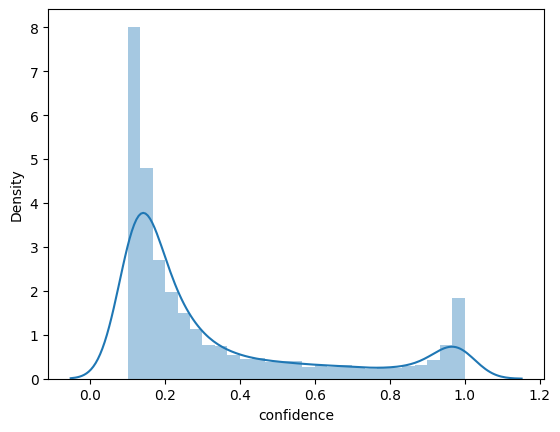

In [22]:
sns.distplot(complete_data_frame['confidence'])

<AxesSubplot: xlabel='device_name'>

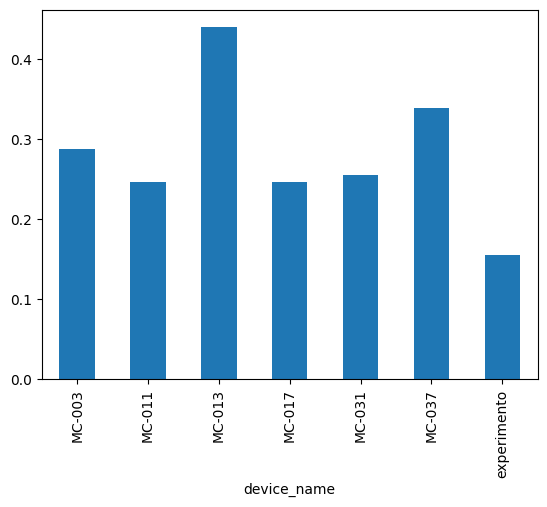

In [26]:
complete_data_frame.groupby('device_name')['confidence'].mean().plot(kind='bar')

<AxesSubplot: xlabel='device_name', ylabel='confidence'>

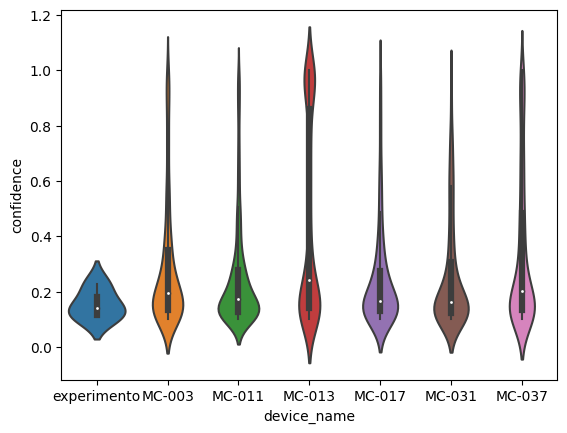

In [31]:
sns.violinplot(data=complete_data_frame[['device_name','confidence']].astype({'confidence':'float64'}) ,
            x='device_name',
            y='confidence'
           )